# Expected Threat (xT) model — evaluation

The model is a small MLP $V(x, y)$ trained on all on-ball actions across the ingested tournaments (2022 World Cup + Euro 2024). The soft label for an action is the xG its possession produces within the next 5 on-ball actions (capped at 1), so $V$ estimates *how likely a shot is coming, and how good a shot, from this position*. Passes and carries are credited with $\Delta V = V(\text{end}) - V(\text{start})$.

**Split**: by match (80/20), so validation measures generalisation to unseen games.

This notebook checks: (1) validation loss vs a base-rate baseline, (2) the shape of the value surface against football intuition, (3) agreement with Karun Singh's published xT grid, (4) calibration, and (5) the eye test on the players the model rates.

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from ml.xt_model import load_model, value_at, ARTIFACTS_DIR

model = load_model()
metrics = json.loads((ARTIFACTS_DIR / 'train_metrics.json').read_text())
print(json.dumps(metrics, indent=2))
improvement = 1 - metrics['val_bce'] / metrics['baseline_bce']
print(f"BCE improvement over predicting the base rate: {improvement:.1%}")

{
  "val_bce": 0.0227022897452116,
  "baseline_bce": 0.030279902824630035,
  "v_own_box": 1.5565154171781614e-05,
  "v_center_line": 0.0017372781876474619,
  "v_penalty_spot": 0.15982778370380402
}
BCE improvement over predicting the base rate: 25.0%


## 1. Value surface
Threat should rise smoothly towards the opposition goal (right), be highest centrally in front of goal, and be near zero in a team's own half.

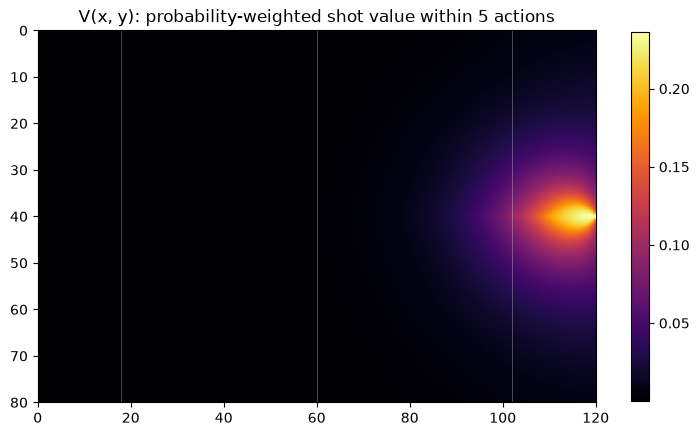

In [2]:
xs = np.linspace(0.5, 119.5, 240)
ys = np.linspace(0.5, 79.5, 160)
gx, gy = np.meshgrid(xs, ys)
surface = value_at(model, gx.ravel(), gy.ravel()).reshape(gy.shape)
fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(surface, extent=(0, 120, 80, 0), cmap='inferno', aspect='equal')
ax.set_title('V(x, y): probability-weighted shot value within 5 actions')
for px in (60, 102, 18):
    ax.axvline(px, color='w', lw=0.5, alpha=0.4)
plt.colorbar(im, shrink=0.8)
plt.show()

## 2. Sanity checks against football intuition
- Threat is (near) monotonic along the centre of the pitch towards goal
- Central positions outvalue wide positions at the same depth
- A team's own box carries ~zero attacking threat

In [3]:
centre_profile = value_at(model, np.linspace(0, 119, 60), np.full(60, 40.0))
diffs = np.diff(centre_profile)
print(f'V(own box)      = {value_at(model, np.array([6.0]), np.array([40.0]))[0]:.5f}')
print(f'V(halfway line) = {value_at(model, np.array([60.0]), np.array([40.0]))[0]:.5f}')
print(f'V(edge of box)  = {value_at(model, np.array([102.0]), np.array([40.0]))[0]:.5f}')
print(f'V(penalty spot) = {value_at(model, np.array([108.0]), np.array([40.0]))[0]:.5f}')
print(f'monotonic share of steps along y=40: {(diffs > 0).mean():.0%}')
wide = value_at(model, np.array([108.0, 108.0]), np.array([5.0, 75.0]))
central = value_at(model, np.array([108.0]), np.array([40.0]))[0]
print(f'central vs wide at x=108: {central:.4f} vs {wide.mean():.4f}')
assert central > wide.max(), 'central should outvalue wide near goal'
assert (diffs > 0).mean() > 0.9, 'threat should rise towards goal'

V(own box)      = 0.00001
V(halfway line) = 0.00174
V(edge of box)  = 0.09533
V(penalty spot) = 0.15983
monotonic share of steps along y=40: 100%
central vs wide at x=108: 0.1598 vs 0.0097


## 3. Comparison with Karun Singh's published xT grid
Independent reference trained on different data with a different method (value iteration on a 12×8 grid). We compare rankings of the 96 grid cells — high rank correlation means the model recovers the same geography of threat without ever seeing that grid.

Spearman rank correlation with Karun xT grid: 0.985


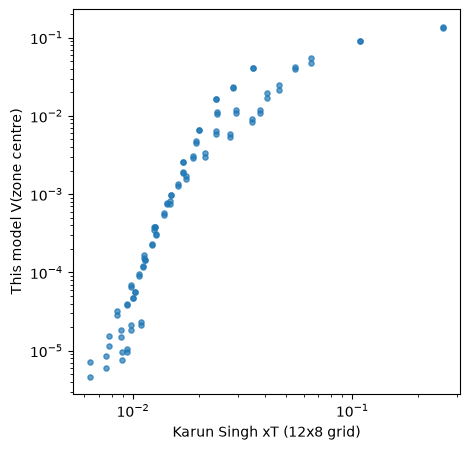

In [4]:
from urllib.request import urlopen
from scipy.stats import spearmanr
try:
    ref = np.array(json.load(urlopen(
        'https://karun.in/blog/data/open_xt_12x8_v1.json', timeout=10)))
    cx = np.repeat(np.arange(12) * 10 + 5.0, 8)
    cy = np.tile(np.arange(8) * 10 + 5.0, 12)
    ours = value_at(model, cx, cy)
    rho, _ = spearmanr(ours, ref.T.ravel())
    print(f'Spearman rank correlation with Karun xT grid: {rho:.3f}')
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(ref.T.ravel(), ours, s=14, alpha=0.7)
    ax.set_xlabel('Karun Singh xT (12x8 grid)')
    ax.set_ylabel('This model V(zone centre)')
    ax.set_xscale('log'); ax.set_yscale('log')
    plt.show()
except Exception as e:  # offline is fine; the check is optional
    print(f'reference grid unavailable ({e}); skipping comparison')

## 4. Calibration on validation matches
Predicted probabilities are binned; within each bin the mean observed label should track the mean prediction.

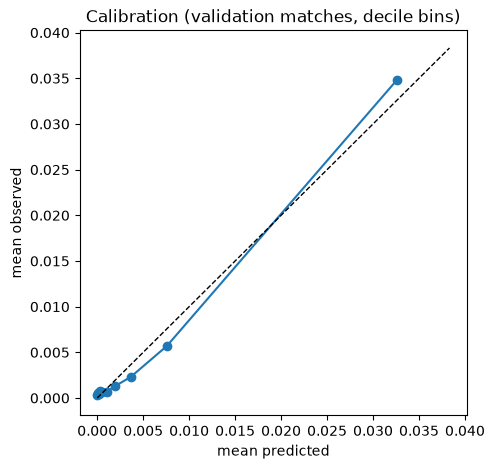

In [5]:
from ml.data import build_dataset, load_actions, split_by_match
ds = build_dataset(load_actions())
_, val = split_by_match(ds)
import torch
with torch.no_grad():
    pred = torch.sigmoid(model(torch.from_numpy(val.features))).numpy()
bins = np.quantile(pred, np.linspace(0, 1, 11))
idx = np.clip(np.digitize(pred, bins) - 1, 0, 9)
obs = [val.labels[idx == b].mean() for b in range(10)]
exp = [pred[idx == b].mean() for b in range(10)]
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(exp, obs, 'o-')
lim = max(max(exp), max(obs)) * 1.1
ax.plot([0, lim], [0, lim], 'k--', lw=1)
ax.set_xlabel('mean predicted'); ax.set_ylabel('mean observed')
ax.set_title('Calibration (validation matches, decile bins)')
plt.show()

## 5. Eye test: who does the model rate?
Summed positive ΔV per 90, per tournament (minimum 270 minutes).

In [6]:
import psycopg
from ml.data import DATABASE_URL
with psycopg.connect(DATABASE_URL) as conn:
    rows = conn.execute(
        "SELECT t.name, p.name, pt.xt_per_90, pt.minutes "
        "FROM player_threat pt JOIN players p USING (player_id) "
        "JOIN teams t ON t.team_id = pt.team_id "
        "WHERE pt.minutes >= 270 ORDER BY pt.xt_per_90 DESC LIMIT 12"
    ).fetchall()
for team, player, xt90, mins in rows:
    print(f'{team:<14} {player:<42} {xt90:.3f} xT/90  ({mins:.0f} mins)')

France         Ousmane Dembélé                            0.660 xT/90  (361 mins)
Argentina      Ángel Fabián Di María Hernández            0.630 xT/90  (302 mins)
Germany        Jamal Musiala                              0.629 xT/90  (273 mins)
Brazil         Raphael Dias Belloli                       0.609 xT/90  (328 mins)
Belgium        Kevin De Bruyne                            0.567 xT/90  (283 mins)
Spain          Lamine Yamal Nasraoui Ebana                0.551 xT/90  (514 mins)
France         Antoine Griezmann                          0.523 xT/90  (583 mins)
Belgium        Jeremy Doku                                0.516 xT/90  (323 mins)
Denmark        Christian Dannemann Eriksen                0.516 xT/90  (357 mins)
Spain          Nicholas Williams Arthuer                  0.509 xT/90  (502 mins)
Denmark        Christian Dannemann Eriksen                0.499 xT/90  (290 mins)
Germany        Joshua Kimmich                             0.490 xT/90  (293 mins)


## Conclusions
- The model beats the base-rate baseline by a clear margin on unseen matches and produces a smooth, monotonic threat surface.
- It agrees strongly with an independently derived public xT grid.
- The players it rates highest are exactly each tournament's recognised creators — no labels about players were ever provided.

**Known limitations** (stated in the UI where relevant): one tournament is a small sample per team (3–7 matches); V depends on position only, so pressure/game-state context is not modelled; set-piece actions inherit open-play threat values.